<a href="https://colab.research.google.com/github/dyiora/eda-carprices/blob/main/eda_carprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as ppl
import seaborn as sns
df = pd.read_csv("/content/cardekho.csv")

In [3]:
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [4]:
df.dtypes


,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage(km/ltr/kg),float64
engine,float64


In [5]:
df.isnull().sum().sum()

foiz=df.isnull().sum()/len(df)*100
print(foiz.sort_values(ascending=False))

#df does not have mostly null-containing columns, so no need for a column drop

seats                 2.718996
mileage(km/ltr/kg)    2.718996
engine                2.718996
max_power             2.645177
km_driven             0.000000
selling_price         0.000000
year                  0.000000
name                  0.000000
owner                 0.000000
transmission          0.000000
seller_type           0.000000
fuel                  0.000000
dtype: float64


In [6]:
t=pd.to_numeric(df["max_power"], errors="coerce")
m=t.isna() & df["max_power"].notna()
df.loc[m, "max_power"]
df.loc[4933, 'max_power']

' '

In [7]:
df.at[4933, 'max_power']=t.mean()
df.loc[4933, 'max_power']
df["max_power"]=df["max_power"].astype(float)

In [8]:
df.duplicated()
df.drop_duplicates(inplace=True)

In [9]:
objects=df.select_dtypes(include="object").columns
numbers=df.select_dtypes(include="number").columns
df[objects]=df[objects].fillna("None")
df[numbers]=df[numbers].fillna(df[numbers].mean())

In [10]:
df.isnull().sum().sum()


np.int64(0)

In [11]:
Q1=df['selling_price'].quantile(0.25)
Q3 = df["selling_price"].quantile(0.75)
IQR = Q3-Q1
m2 = (df["selling_price"]>=Q1-1.5*IQR) &\
       (df["selling_price"]<=Q3+1.5*IQR)

df_clean = df[m2]
print(df_clean)

                                   name  year  selling_price  km_driven  \
0                Maruti Swift Dzire VDI  2014         450000     145500   
1          Skoda Rapid 1.5 TDI Ambition  2014         370000     120000   
2              Honda City 2017-2020 EXi  2006         158000     140000   
3             Hyundai i20 Sportz Diesel  2010         225000     127000   
4                Maruti Swift VXI BSIII  2007         130000     120000   
...                                 ...   ...            ...        ...   
8121  Maruti Wagon R VXI BS IV with ABS  2013         260000      50000   
8122         Hyundai i20 Magna 1.4 CRDi  2014         475000      80000   
8123                  Hyundai i20 Magna  2013         320000     110000   
8124              Hyundai Verna CRDi SX  2007         135000     119000   
8125             Maruti Swift Dzire ZDi  2009         382000     120000   

        fuel seller_type transmission                 owner  \
0     Diesel  Individual       Manua

In [12]:
df_clean.duplicated().sum()

np.int64(0)

In [13]:
df_clean.isnull().sum().sum()

np.int64(0)

In [14]:
sns.set_theme(palette="viridis")

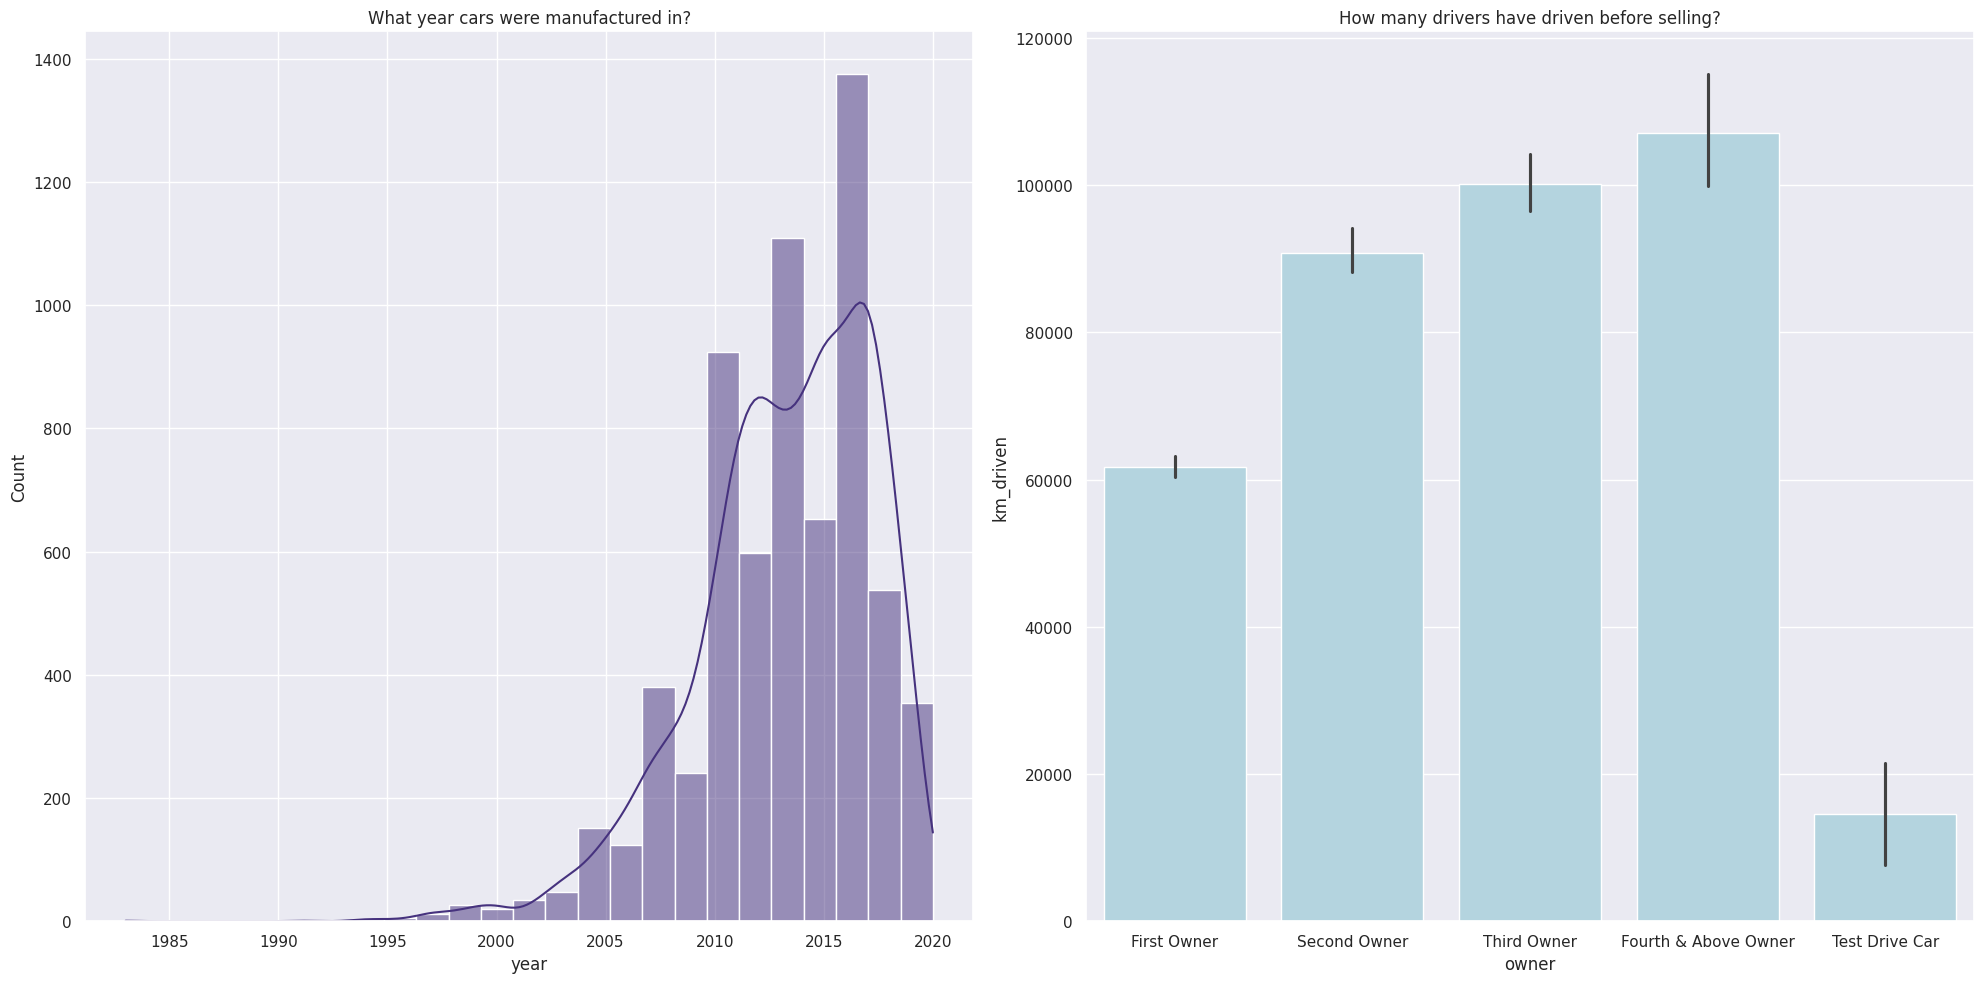

In [15]:
f, a = ppl.subplots(1, 2, figsize=(20, 10))
sns.histplot(data=df_clean, x="year", ax=a[0], bins=25,
             kde=True)
a[0].set_title("What year cars were manufactured in?")
sns.barplot(data=df, x="owner", y="km_driven", ax=a[1], color="lightblue")
a[1].set_title("How many drivers have driven before selling?")

ppl.tight_layout()
ppl.show()

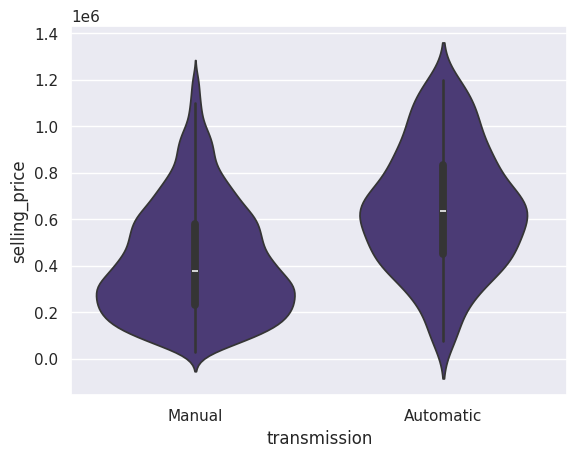

In [16]:
sns.violinplot(data=df_clean, x="transmission", y="selling_price")
ppl.show()

/tmp/ipykernel_6485/2440948812.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_clean, x="fuel", y="selling_price", palette="mako")


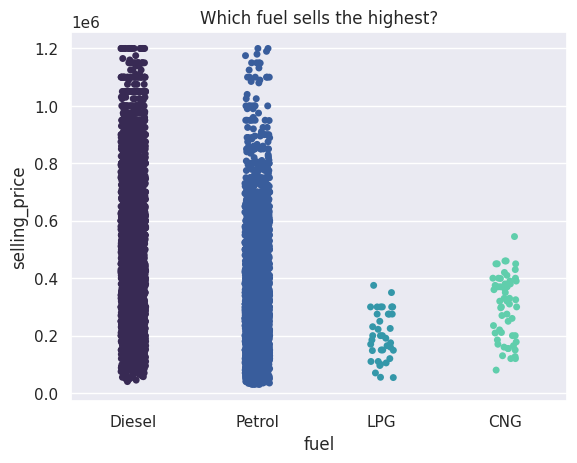

In [17]:
sns.stripplot(data=df_clean, x="fuel", y="selling_price", palette="mako")
ppl.title("Which fuel sells the highest?")
ppl.show()


/tmp/ipykernel_6485/255073530.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="fuel", y="selling_price", palette="magma")


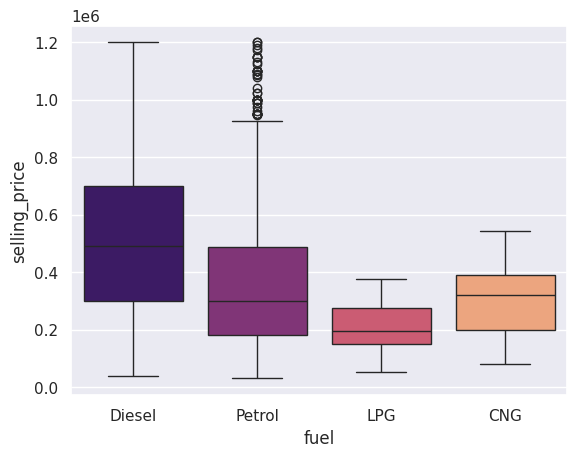

In [18]:
sns.boxplot(data=df_clean, x="fuel", y="selling_price", palette="magma")
ppl.show()

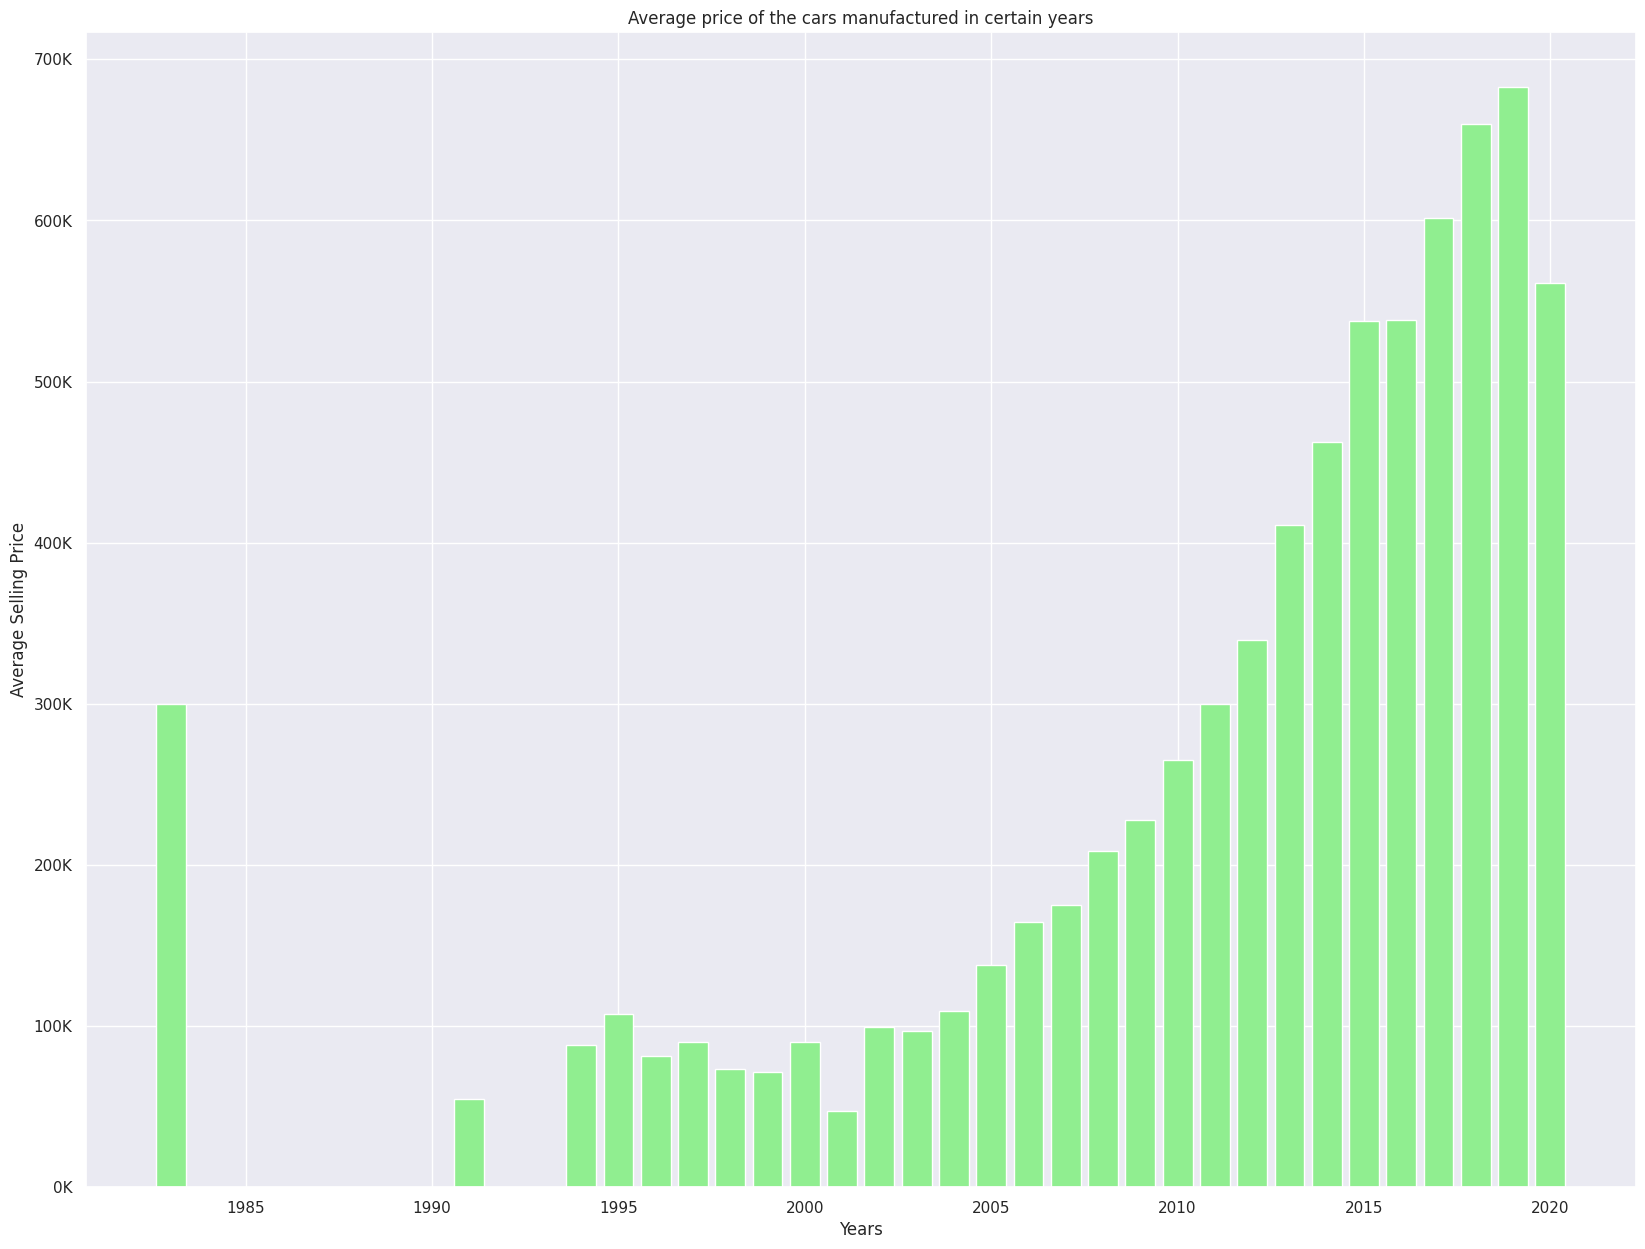

In [36]:
import matplotlib.ticker as tc
avg_saleprice = df_clean.groupby("year")["selling_price"].mean().reset_index()
ppl.figure(figsize=(20, 15))
ppl.gca().yaxis.set_major_formatter(tc.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

ppl.bar(avg_saleprice["year"], avg_saleprice["selling_price"],
        color="lightgreen")
ppl.xlabel("Years")
ppl.ylabel("Average Selling Price")
ppl.title("Average price of the cars manufactured in certain years")


ppl.show()

<Axes: xlabel='max_power', ylabel='selling_price'>

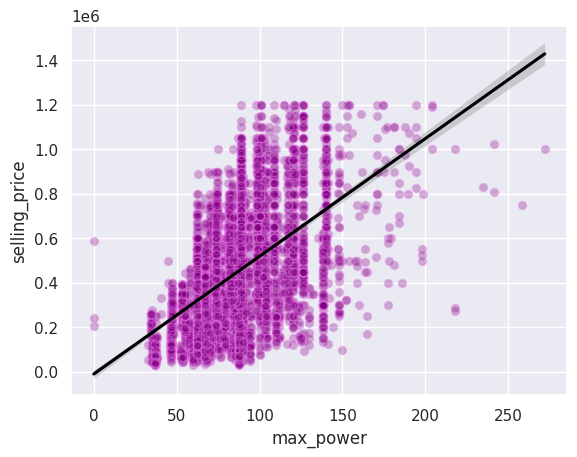

In [37]:
sns.regplot(data=df_clean, x="max_power", y="selling_price",
            line_kws={"color": "black"},
            scatter_kws={"color": "purple", "alpha": 0.3, "edgecolor": "violet"})

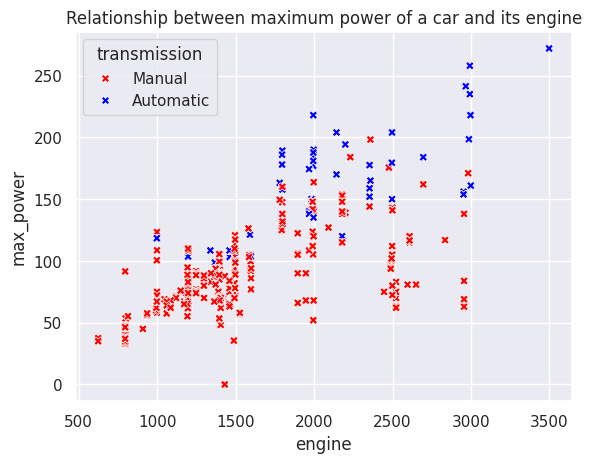

In [38]:
sns.scatterplot(data=df_clean, x="engine", y="max_power",
                hue="transmission", palette={"Manual": "red", "Automatic": "blue"}, marker="X")
ppl.title("Relationship between maximum power of a car and its engine")
ppl.show()

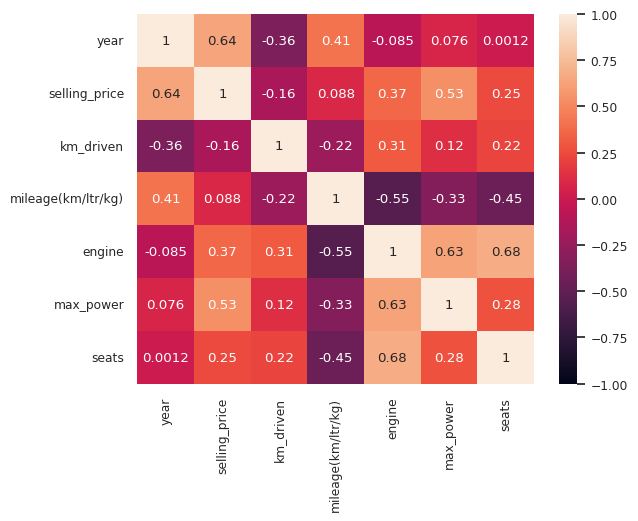

In [39]:
with sns.plotting_context(font_scale=0.8, context="notebook"):
  sns.heatmap(df_clean[numbers].corr(), annot=True, vmin=-1, vmax=1)
ppl.show()

<Figure size 4500x2500 with 0 Axes>

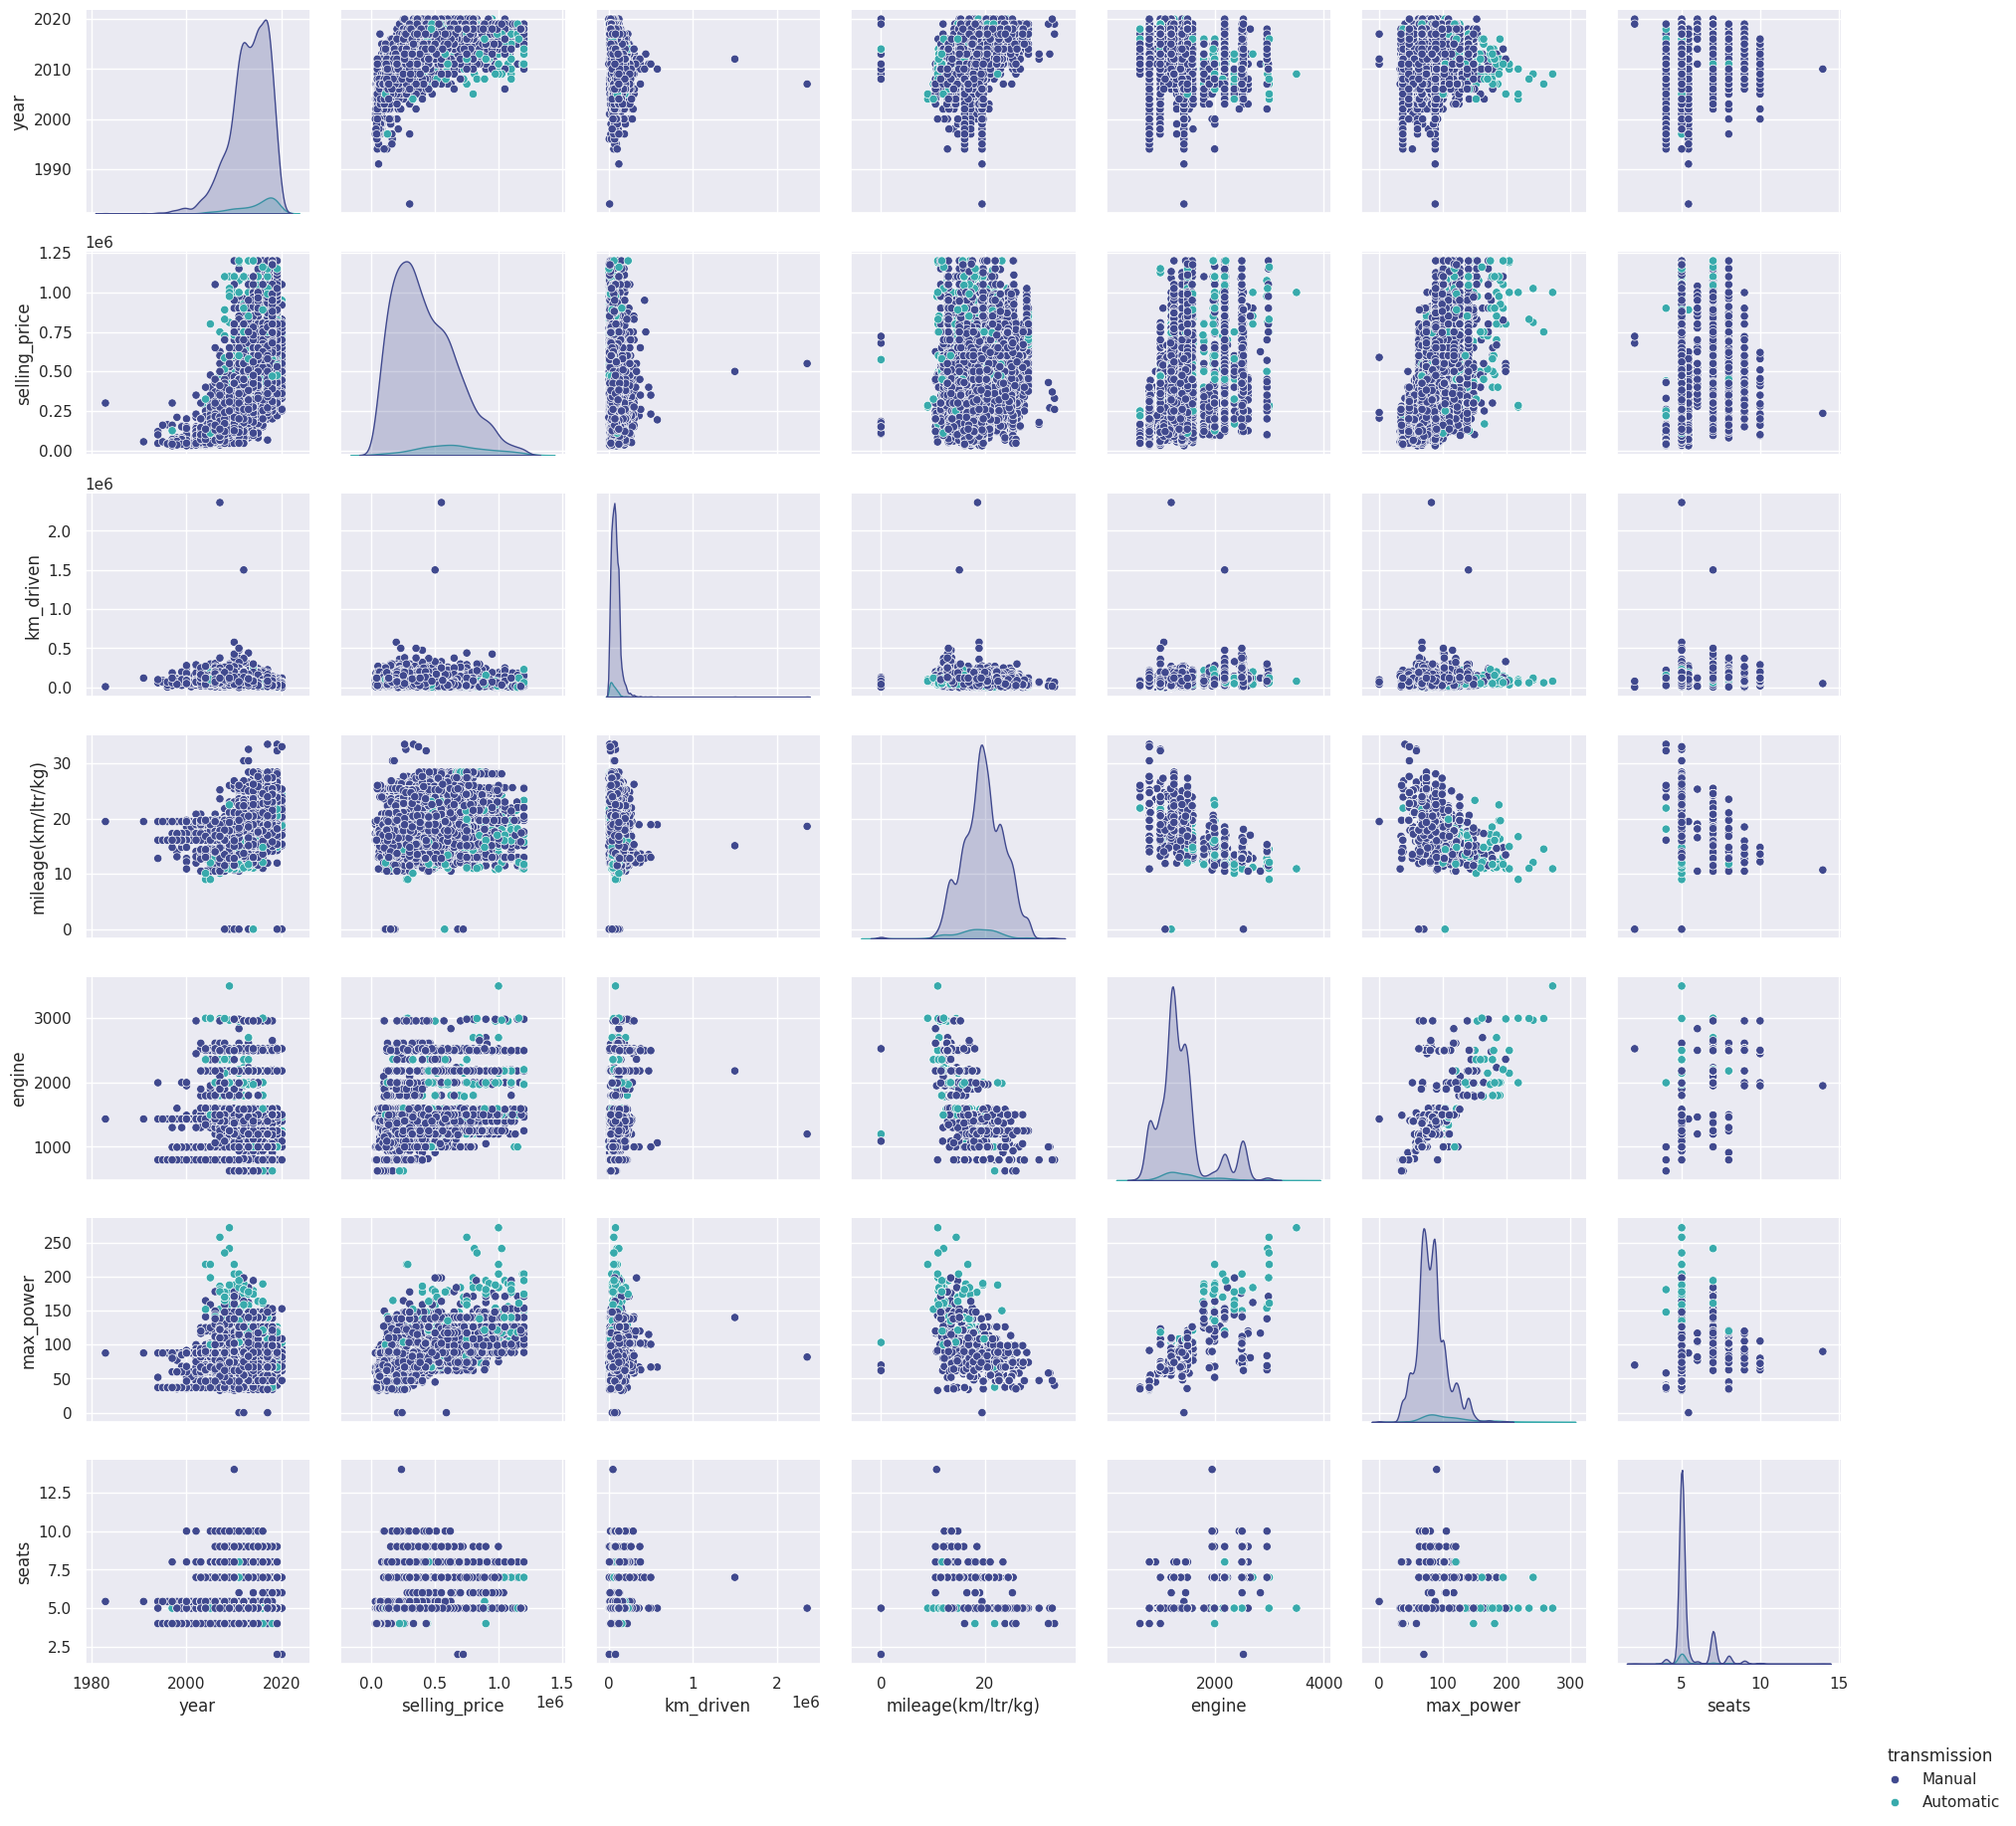

In [40]:
ppl.figure(figsize=(45, 25))
ax=sns.pairplot(data=df_clean, hue="transmission", palette="mako")
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1, 0))
ppl.tight_layout()
ppl.show()